In [1]:
# Importing required libraries for Linear regression model training
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Loading the dataset
df = pd.read_csv(r"D:\AIML_ASSG\student-performance-project\data\grade_data.csv")

The dataset Predict student grades based on study habits, attendance, sleep, and socioeconomic background

In [3]:
# Inspecting the dataset
df.head(5)

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
0,0.95822,3.4,8.2,53.0,47.0
1,0.85566,3.2,5.9,55.0,35.0
2,0.68025,3.2,9.3,41.0,32.0
3,0.25936,3.2,8.2,47.0,34.0
4,0.60447,3.8,10.0,75.0,33.0


In [4]:
df.sample(10)

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
786,0.83476,8.3,7.2,98.0,59.0
997,0.27553,7.9,9.0,64.0,54.0
1014,0.47071,3.6,8.2,71.0,33.0
28,0.73168,5.9,8.1,58.0,45.0
468,0.97943,3.1,8.7,40.0,48.0
477,0.77330,5.7,7.8,47.0,44.0
4,0.60447,3.8,10.0,75.0,33.0
773,0.46855,6.6,8.7,64.0,45.0
113,0.70763,3.7,8.1,67.0,35.0
822,0.73135,8.3,6.1,57.0,56.0


In [5]:
#Check number of rows and comlumns
df.shape

(1388, 5)

In [6]:
# check for any misiing values
df.isnull().sum()

Socioeconomic Score    0
Study Hours            0
Sleep Hours            0
Attendance (%)         0
Grades                 0
dtype: int64

In [7]:
# getting information of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1388 entries, 0 to 1387
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Socioeconomic Score  1388 non-null   float64
 1   Study Hours          1388 non-null   float64
 2   Sleep Hours          1388 non-null   float64
 3   Attendance (%)       1388 non-null   float64
 4   Grades               1388 non-null   float64
dtypes: float64(5)
memory usage: 54.3 KB


Information reveals that all columns are numerical and have no missing values

In [8]:
# Genrating summary statistics
df.describe()

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
count,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000
mean,0.552274,4.560807,8.047262,58.536023,40.691643
std,0.261272,1.897581,1.370700,11.675287,9.467358
min,0.101280,0.800000,4.800000,40.000000,32.000000
25%,0.322118,3.475000,7.000000,49.000000,34.000000
50%,0.545945,3.900000,8.400000,57.000000,35.000000
75%,0.789610,5.900000,9.100000,66.000000,47.000000
max,0.999820,10.000000,10.000000,100.000000,91.000000


Key insights from descritive analyis are:

Variables contain valid numerical values(No negative numbers, within rage)
Students study an average of 4.56 hours and sleep approximately 8 hours per day
Average attendance is 58.54%
Mean grade is 40.69
Dataset shows reasonable variation across all features

In [9]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [10]:
# corelation matrix for the variables
df.corr()

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
Socioeconomic Score,1.000000,0.002151,0.013618,-0.022793,0.335033
Study Hours,0.002151,1.000000,-0.187204,0.485408,0.810807
Sleep Hours,0.013618,-0.187204,1.000000,-0.105758,-0.124689
Attendance (%),-0.022793,0.485408,-0.105758,1.000000,0.321930
Grades,0.335033,0.810807,-0.124689,0.321930,1.000000


Study Hours have strong positive corelation with Grades

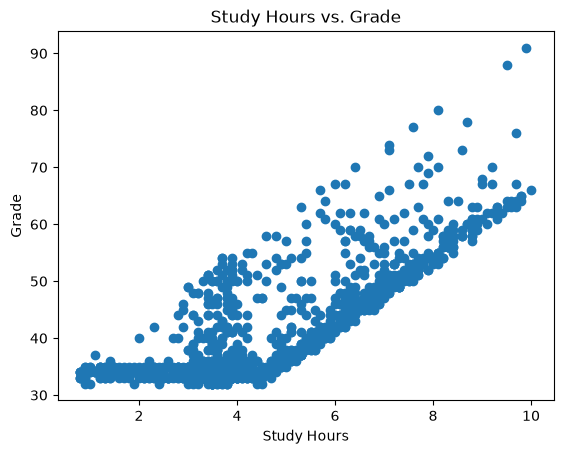

In [11]:
# we can draw scatter plot between study hours and grades
import matplotlib.pyplot as plt
plt.scatter(df['Study Hours'], df['Grades'])
plt.xlabel('Study Hours')
plt.ylabel('Grade')
plt.title('Study Hours vs. Grade')
plt.show()

In [12]:
X = df[['Socioeconomic Score', 'Study Hours', 'Sleep Hours', 'Attendance (%)']]
y = df['Grades']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Selecting model apart from linear regression model
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[12.17, 4.26, 0.19,-0.07]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Socioeconomic Score','Study Hours','Sleep Hours','Attendance (%)']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,16.94
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [13]:
acc_score = model.score(X_train, y_train)
print(f"Score of the model: {acc_score}")

Score of the model: 0.7797627201382422


In [14]:
# Giving manual values to model for making predicion
model.predict([[0.86,3.5,7,80]])

c:\Users\Malik\anaconda3\envs\aiml_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([38.34935015])

In [15]:
model.intercept_

np.float64(16.936552069182024)

In [16]:
model.coef_

array([12.16611441,  4.26401171,  0.19064832, -0.06635799])

In [17]:
predicted_grade = 12.16611441 * 0.86 + 4.26401171 * 3.5 +  0.19064832 * 7 + -0.06635799 * 80 + 16.93655206918198
print(predicted_grade)

38.34935048678199


In [18]:
# evaluating the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Root Mean Squared Error: {rmse:.2f}, indicating difference between acutal and predicted grades")

Mean Squared Error: 19.27253772875125
R-squared: 0.7446674729714069
Root Mean Squared Error: 4.39, indicating difference between acutal and predicted grades


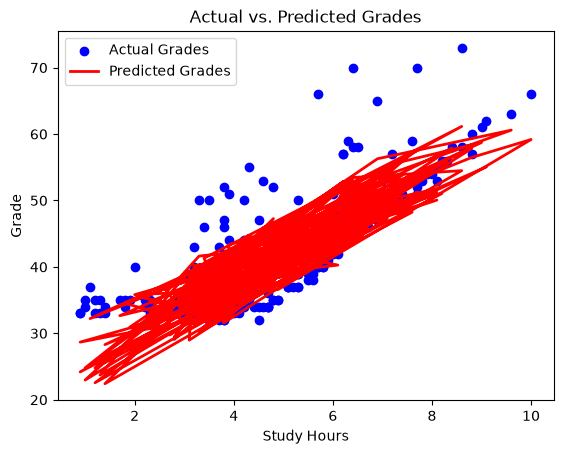

In [19]:
# scatter plot drawing line for linear model evaluation
plt.scatter(X_test['Study Hours'], y_test, color='blue', label='Actual Grades')
plt.plot(X_test['Study Hours'], y_pred, color='red', linewidth=2, label='Predicted Grades')
plt.xlabel('Study Hours')
plt.ylabel('Grade')
plt.title('Actual vs. Predicted Grades')
plt.legend()
plt.show()